In [1]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
from io import StringIO

In [6]:
def get_sorted(dic):
    return [dic[k] for k in list(map(str,sorted(list(map(int, dic.keys())))))]

def get_betas(folder):
    betas = {}
    pattern = re.compile(r"Beta \s=\s(?P<value>[0-9]*\.[0-9]*)")
    for run in [f for f in next(os.walk(folder))[1] if f != 'lightning_logs']:
        n_run = run.split('_')[-1]
        with open(os.path.join(folder,run,'out.txt')) as f:
            txt = f.read()
            match  = pattern.search(txt)
            if match is not None:
                betas[n_run] = match.group('value')
    return betas

# def get_cross_correlation(folder):
#     corr = {}
#     pattern = re.compile(r"\bLatent Dimension 0 \s*[Na0-9\.\-]+\s*(?P<value>[Na0-9\.\-]+)")
#     for run in [f for f in next(os.walk(folder))[1]]:
#         n_run = run.split('_')[-1]
#         with open(os.path.join(folder,run,'out.txt')) as f:
#             txt = f.read()
#             # print(n_run, pattern.findall(txt))
#             match = pattern.findall(txt)
#             if match is not None and len(match) > 0:
#                 match  = match[-1]
#                 if match == 'Nan':
#                     corr[n_run] = float('nan')
#                 else:
#                     corr[n_run] = float(match)
#     return get_sorted(corr)

# def get_labels_cross_correlation(folder):
#     corr = {}
#     pattern = re.compile(r"\bLatent Dimension 0 \s*[Na0-9\.\-]+\s*[Na0-9\.\-]+\s*(?P<value_a>[Na0-9\.\-]+)+\s*(?P<value_b>[Na0-9\.\-]+)[\r\n|\r|\n]Latent Dimension 1 \s*[Na0-9\.\-]+\s*[Na0-9\.\-]+\s*(?P<value_c>[Na0-9\.\-]+)+\s*(?P<value_d>[Na0-9\.\-]+)")
#     for run in [f for f in next(os.walk(folder))[1]]:
#         n_run = run.split('_')[-1]
#         with open(os.path.join(folder,run,'out.txt')) as f:
#             txt = f.read()
#             match = pattern.findall(txt)[-1]
#             if match is not None:
#                 match = [float(val) if val != 'Nan' else float('nan') for val in match ]
#                 corr[n_run] = match
#     return get_sorted(corr)

def get_correlations(folder):
    corr = {}
    for run in [f for f in next(os.walk(folder))[1] if f != 'lightning_logs']:
        n_run = run.split('_')[-1]
        filename = os.path.join(folder,run,'out.txt')
        corrs = read_correlations(filename)
        corr[n_run] = corrs
    return corr


def read_one_correlations(lines, delimiter_char='='):

    start_line = -1
    end_line = -1
    for i in range(len(lines)):
        if lines[i].strip() == delimiter_char * len(lines[i].strip()):
            if start_line == -1:
                start_line = i
            else:
                end_line = i
                break

    if start_line != -1 and end_line != -1:
        data = ''.join(lines[start_line+1:end_line])
        data = data.replace("Latent Dimension 0", "Latent-Dimension-0")
        data = data.replace("Latent Dimension 1", "Latent-Dimension-1")
        return pd.read_csv(StringIO(data), sep=r"\s+", engine='python', index_col = 0)
    else:
        raise Exception("Could not find correlations in file.")


def read_correlations(filename, delimiter_char='='):

    with open(filename, 'r') as file:
        lines = file.readlines()
    corr_list = []
    for i in range(len(lines)):
        if "Correlation of latent space and labels" in lines[i]:
            corr_list.append(read_one_correlations(lines[i:], delimiter_char))
    return corr_list




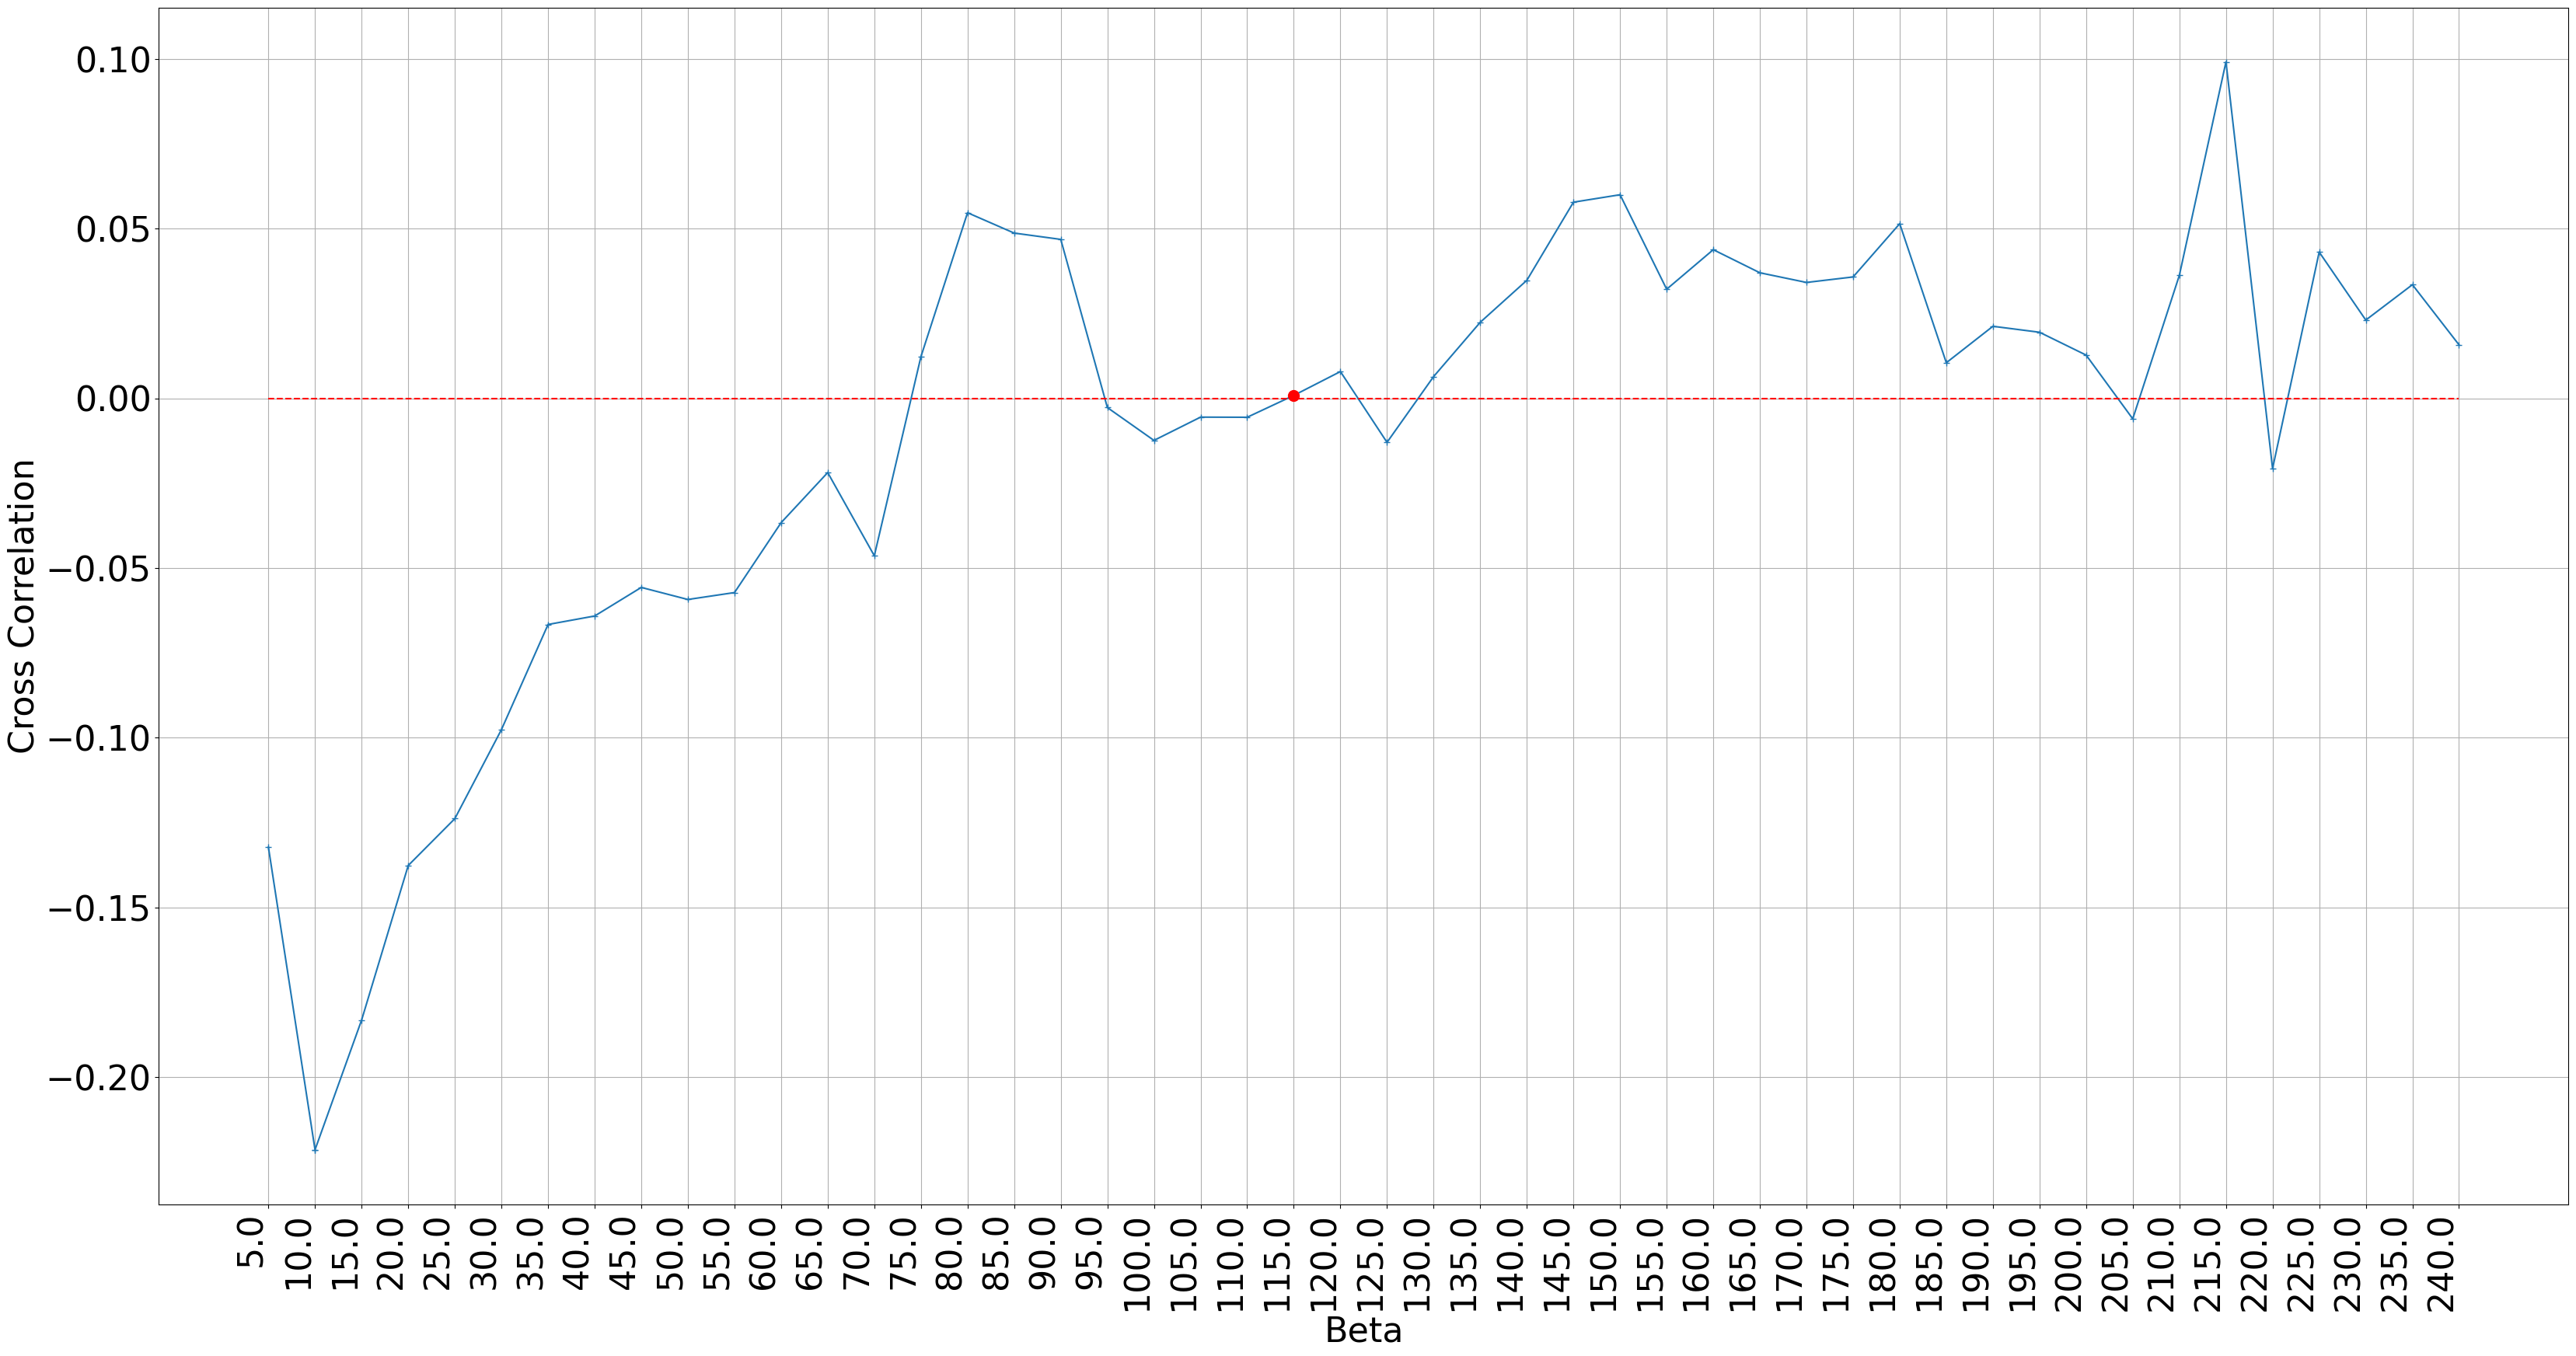

In [10]:
plt.rcParams["figure.figsize"] = (40,20)
plt.rcParams.update({'font.size': 32})
plt.xticks(rotation=90, ha='right')
folder = os.path.join(os.getcwd() +'/saved_runs/beta_search_500_elbo_2/')
all_corrs = get_correlations(folder)
all_betas = get_betas(folder)
correlations = []
betas = []
label_corrs = []
keylists = list(map(int, all_corrs.keys()))
keylists.sort()
keylists = list(map(str, keylists))[:50]
for run in keylists:
    if len(all_corrs[run]) > 0:
        correlations.append(all_corrs[run][-1].iloc[0,1])
        betas.append(all_betas[run])
        label_corrs.append([all_corrs[run][-1].iloc[0,2], all_corrs[run][-1].iloc[0,3], all_corrs[run][-1].iloc[1,2], all_corrs[run][-1].iloc[1,3]])
plt.plot(betas, correlations, '+-')
minarg = np.argmin(np.abs([f if not math.isnan(f) else 1 for f in correlations]))
plt.plot(betas[minarg],correlations[minarg], 'ro', markersize=10)
plt.plot(betas,[0] * len(betas),'--', color='red')
plt.xlabel('Beta')
plt.ylabel('Cross Correlation')
plt.grid()

# correlations

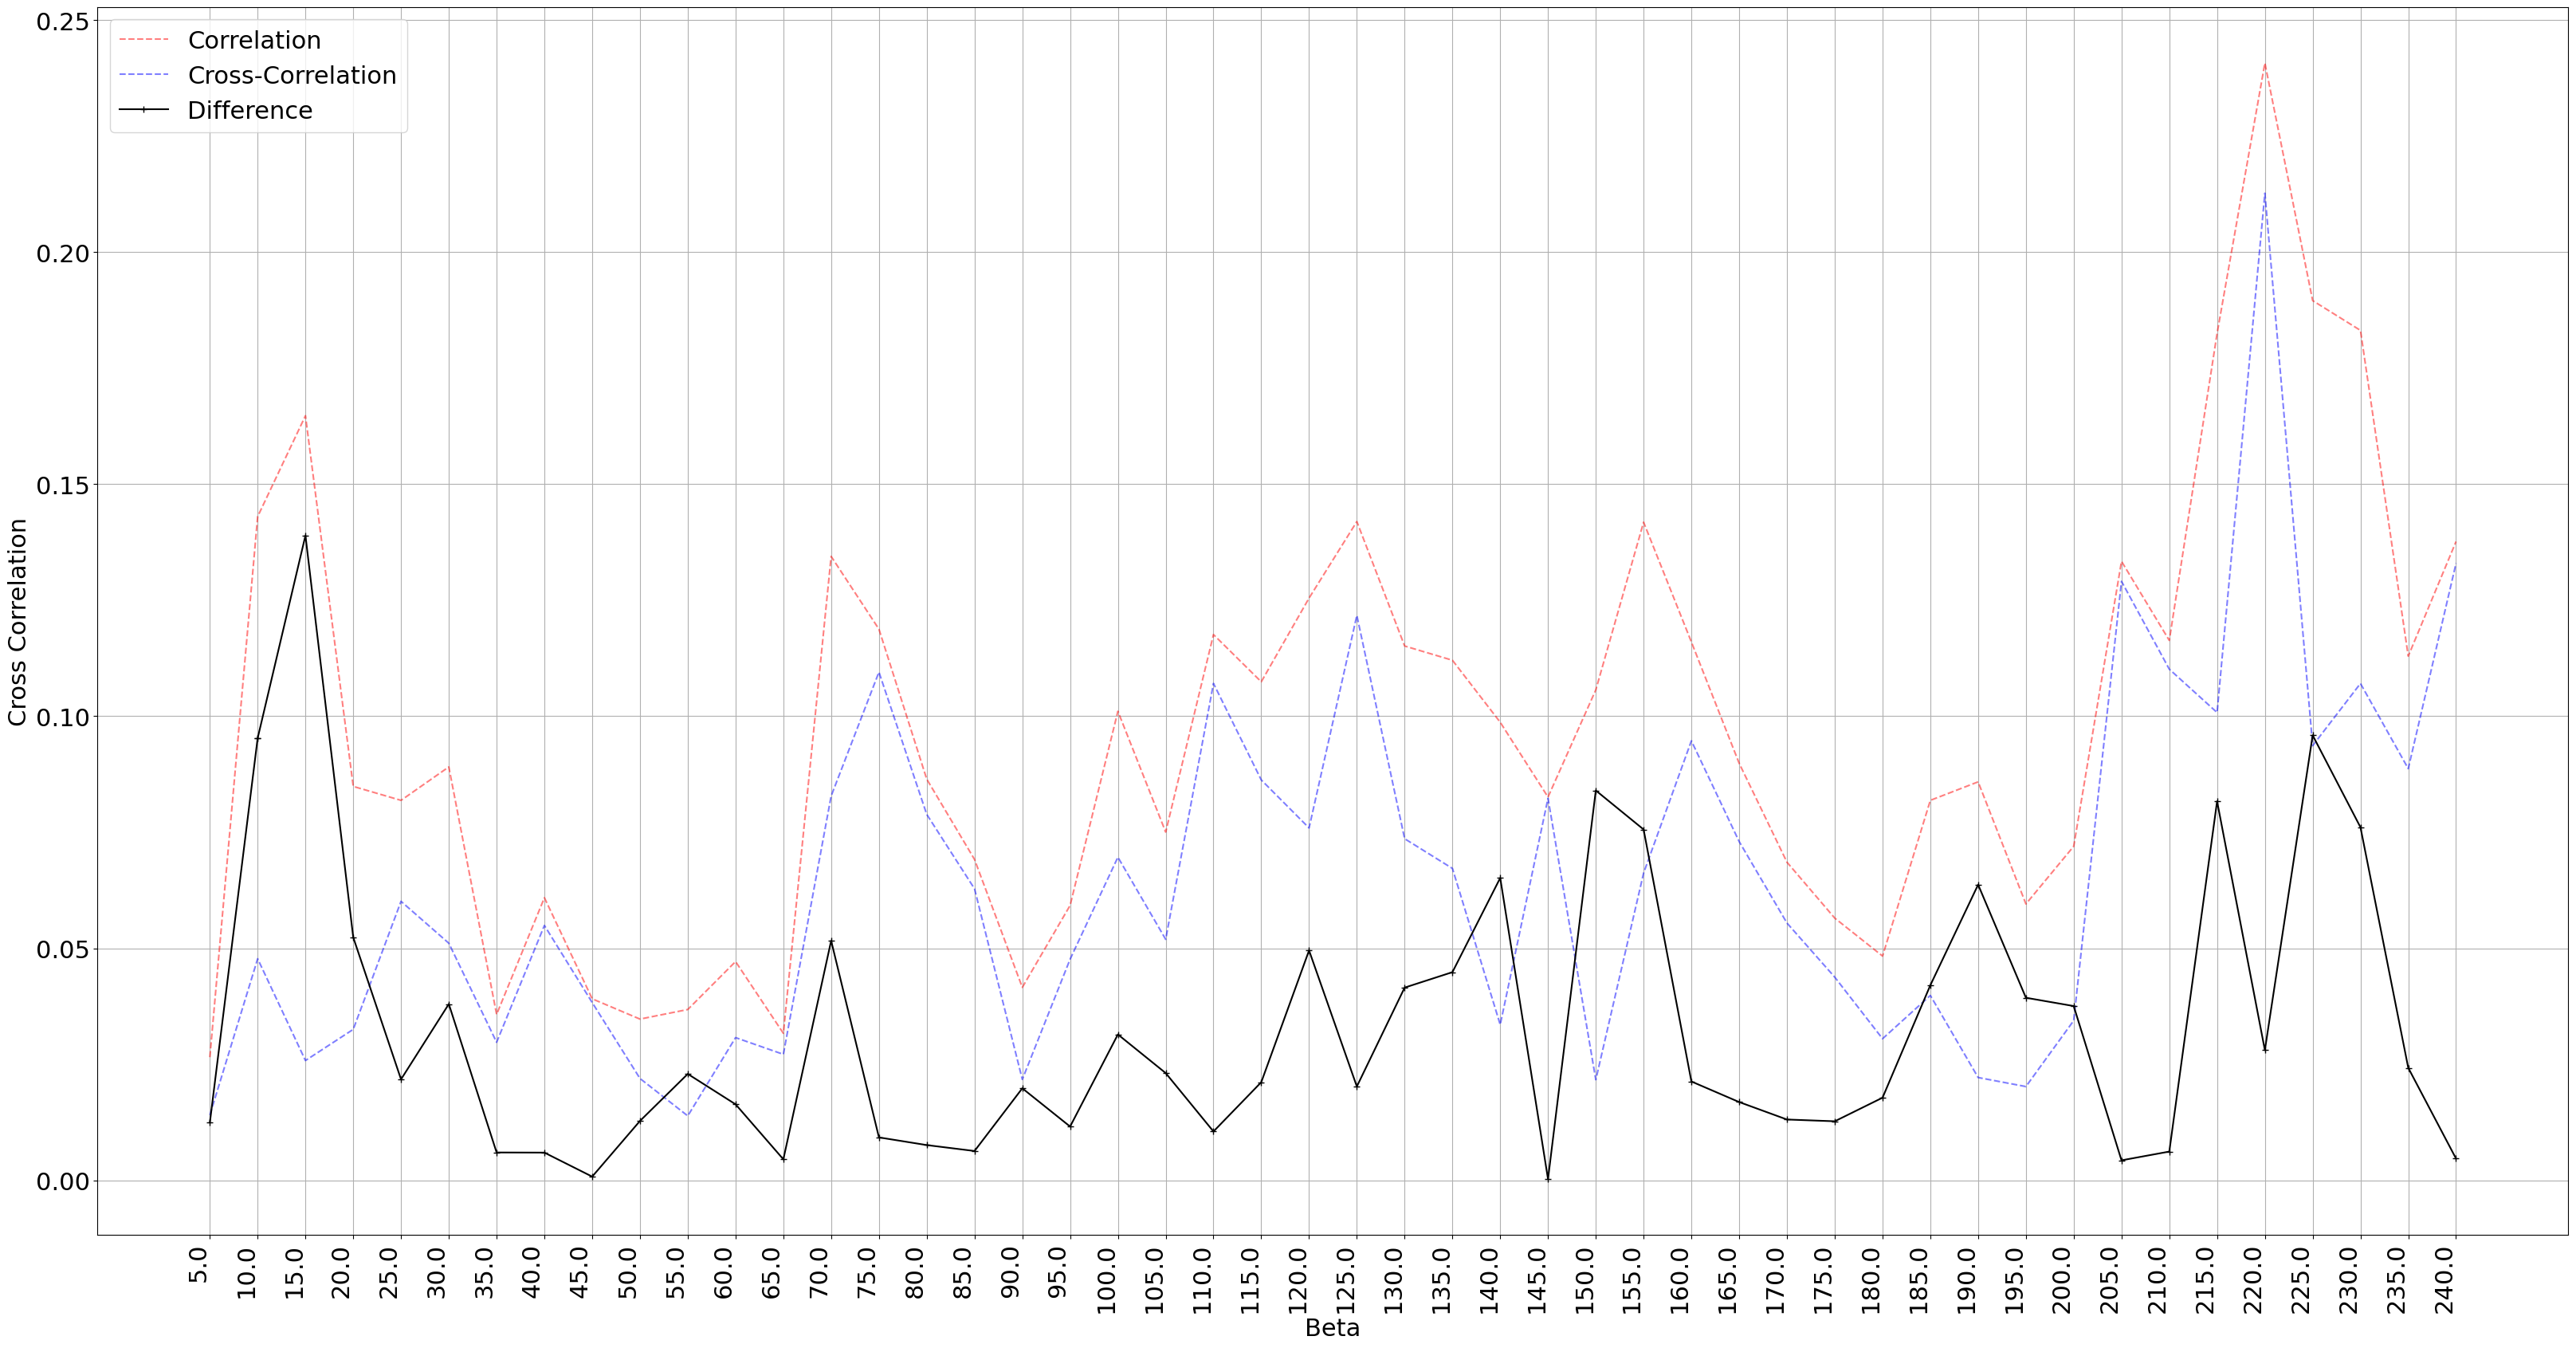

In [143]:
plt.close()
plt.rcParams["figure.figsize"] = (40,20)
plt.rcParams.update({'font.size': 22})
plt.xticks(rotation=90, ha='right')
corr = []
cross = []
for values in label_corrs:
    if True in [math.isnan(val) for val in values]:
        corr.append(float('nan'))
        cross.append(float('nan'))
    else:
        v1 = abs(values[0])+abs(values[3])
        v2 = abs(values[1])+abs(values[2])
        corr.append(max(v1,v2))
        cross.append(min(v1,v2))
diff  = [x-y for x,y in zip(corr,cross)]
plt.plot(betas,corr, 'r--', label='Correlation', alpha=0.5)
plt.plot(betas,cross, 'b--', label='Cross-Correlation', alpha=0.5)
plt.plot(betas,diff, '+-', color='black', label='Difference')
plt.xlabel('Beta')
plt.ylabel('Cross Correlation')
plt.grid()
plt.legend()